In [2]:
#On terminal: python -m pip install -e .

# The Catareing Service Problem

## Data

In [22]:
napkins_demanded = {'day1':23, 'day2':14, 'day3':19, 'day4':21, 'day5':18, 
                  'day6':14, 'day7':15}

fast_cost = 0.75 # fast delivery cost per napkin (2 days)
slow_cost = 0.5 # slow delivery cost per napkin (4 days)  
buy_cost  = 3   # cost of buying a napkin from the supplier


## Netowrk Representation

In [4]:
from network_simplex import Node, Arc, Network
# Preliminaries
P_nodes_names = ['P'+'_'+str(i) for i in range(7+1)]
Q_nodes_names = ['Q'+'_'+str(i) for i in range(7+1)]
enough_napkins = sum(napkins_demanded.values())+1
# NODES
Data_NODES = []
# Auxliary nodes
Data_NODES.append(Node(P_nodes_names[0], enough_napkins))
Data_NODES.append(Node(Q_nodes_names[0], -enough_napkins))
# The rest of the nodes
for i in range(1, 7+1):
    # Supply nodes
    Data_NODES.append(Node(P_nodes_names[i], napkins_demanded['day'+str(i)]))
    # Demand nodes  
    Data_NODES.append(Node(Q_nodes_names[i], -napkins_demanded['day'+str(i)]))

# ARCS
Data_ARCS = []
# Arcs with respect to Q_0 (auxiliary node)
Data_ARCS.append(
        Arc(id=f'P_0 -> Q_0',
            tail='P_0', 
            head='Q_0',
            cost=0)
    )
Data_ARCS.append(
        Arc(id=f'P_7 -> Q_0',
            tail='P_7', 
            head='Q_0',
            cost=0)
    )
# Arcs from P_0 to all Q_i (buying napkins from the supplier)
for i in Q_nodes_names[1:]:
    Data_ARCS.append(
        Arc(id=f'P_0 -> {i}',
            tail=P_nodes_names[0], 
            head=i,
            cost=3)
    )
# Arcs from P_i to Q_j (delivery of napkins) 
for i,Pnode in enumerate(P_nodes_names[1:]):
    i+=1 # to correct zero indexing
    if i+4 <=7: 
        # SLOW DELIVERY (4 days)
        Data_ARCS.append(
            Arc(id=f'{Pnode} -> {Q_nodes_names[i+4]}',
                tail=Pnode, 
                head=Q_nodes_names[i+4],
                cost=slow_cost)
        )
        # FAST DELIVERY (2 days)
        Data_ARCS.append(
                    Arc(id=f'{Pnode} -> {Q_nodes_names[i+2]}',
                        tail=Pnode, 
                        head=Q_nodes_names[i+2],
                        cost=fast_cost)
                )

    elif i+2 <=7:
        # Only FAST DELIVERY available (2 days)
        Data_ARCS.append(
                    Arc(id=f'{Pnode} -> {Q_nodes_names[i+2]}',
                        tail=Pnode, 
                        head=Q_nodes_names[i+2],
                        cost=fast_cost)
                )

# Carrying napkins from day i to day i+1 (cost=0)
for i in range(1,7):
    Data_ARCS.append(
        Arc(id=f'{P_nodes_names[i]} -> {P_nodes_names[i+1]}',
            tail=P_nodes_names[i], 
            head=P_nodes_names[i+1],
            cost=0)
    )
Catering_Network = Network(Data_NODES, Data_ARCS)

### Visualization using networkx

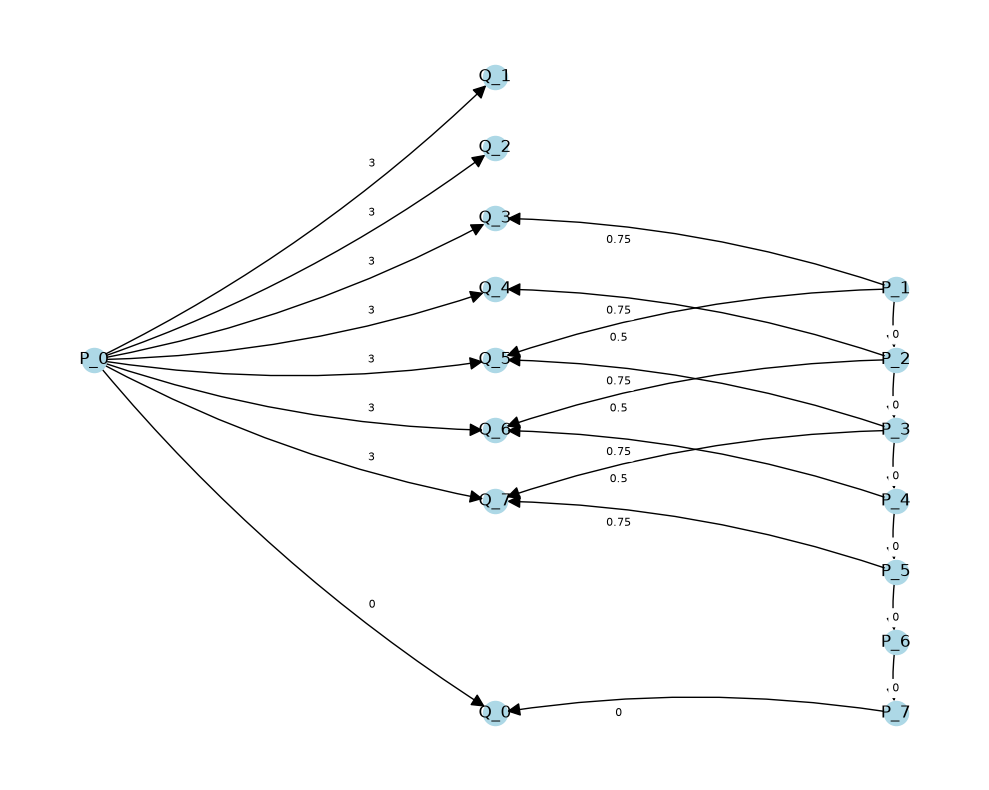

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_nodes_from(list(Catering_Network.nodes))
for id, arc in Catering_Network.arcs.items():
    G.add_edge(arc.tail, arc.head, id=id, cost=arc.cost)

pos = {}
pos['P_0'] = (0, 0)
pos['Q_0'] = (1, -5)
shift = +4
for i, node in enumerate(Q_nodes_names[1:]):
    pos[node] = (1, -i + shift)

shift = 1
for i, node in enumerate(P_nodes_names[1:]):
    pos[node] = (2, -i + shift)

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color="lightblue")
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    connectionstyle='arc3,rad=0.08'
)

edge_labels = {(u, v): f"{d['cost']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    label_pos=0.7,
    rotate=False,
    font_size=8
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Solving the network simplex problem

### Cold Start

In [6]:
from network_simplex import NetworkSimplex, WarmStart

# Cold Solution - BigM procedure
catering_simplex_problem = NetworkSimplex(Catering_Network)
catering_solution = catering_simplex_problem.solve()

print(f'Objective value: {catering_solution.objective_value}')
print(f'Flows: {catering_solution.flows}')
print(f'Potentials: {catering_solution.potentials}')
print(f'Iterations: {catering_solution.iterations}')
print(f'Basic arcs: {catering_solution.basic_arc_ids}')
print(f'Root: {catering_solution.root}')

Objective value: 182.75
Flows: {'P_0 -> Q_7': 0.0, 'P_1 -> Q_3': 16.0, 'P_2 -> P_3': 0.0, 'P_5 -> P_6': 11.0, 'P_4 -> P_5': 7.0, 'P_3 -> Q_5': 18.0, 'P_6 -> P_7': 25.0, 'P_0 -> Q_0': 85.0, 'P_4 -> Q_6': 14.0, 'P_3 -> P_4': 0.0, 'P_1 -> Q_5': 0.0, 'P_0 -> Q_6': 0.0, 'P_0 -> Q_2': 14.0, 'P_1 -> P_2': 7.0, 'P_7 -> Q_0': 40.0, 'P_2 -> Q_4': 21.0, 'P_0 -> Q_3': 3.0, 'P_0 -> Q_4': 0.0, 'P_0 -> Q_1': 23.0, 'P_2 -> Q_6': 0.0, 'P_5 -> Q_7': 14.0, 'P_3 -> Q_7': 1.0, 'P_0 -> Q_5': 0.0}
Potentials: {'P_1': -420.25, 'Q_7': -418.75, 'Q_2': -421.0, 'Q_5': -419.0, 'Q_0': -418.0, 'P_4': -418.0, 'P_7': -418.0, 'P_2': -420.25, 'Q_3': -421.0, 'Q_6': -418.75, 'P_5': -418.0, 'P_0': -418.0, 'P_3': -418.25, 'Q_1': -421.0, 'Q_4': -421.0, 'P_6': -418.0}
Iterations: 26
Basic arcs: None
Root: None


### Warm Start Solution

In [7]:
# First we define de basic Tree, the flows and the root node for the warm start solution
basic_arc_ids = []
flows = {}
for id, arc in Catering_Network.arcs.items():
    if arc.tail == 'P_0':
        basic_arc_ids.append(id)
        flows[id]= -Catering_Network.nodes[arc.head].balance
    elif arc.tail.startswith('P') and arc.head.startswith('P'):
        basic_arc_ids.append(id)
basic_arc_ids.append('P_7 -> Q_0')
basic_arc_ids.append('P_0 -> Q_0')   

basic_arc_ids = frozenset(basic_arc_ids)
flows['P_0 -> Q_0'] = 1
flows['P_1 -> P_2'] = 23
flows['P_2 -> P_3'] = 37
flows['P_3 -> P_4'] = 56
flows['P_4 -> P_5'] = 77
flows['P_5 -> P_6'] = 95
flows['P_6 -> P_7'] = 109
flows['P_7 -> Q_0'] = 124
for arc in Catering_Network.arcs.keys():
    if arc not in flows.keys():
        flows[arc] = 0

In [8]:
# Create the warm start object
warm_start = WarmStart(
    root='P_0',
    basic_arc_ids= basic_arc_ids,
    flows=flows)

In [9]:
# Solve the problem using the warm start
catering_solution_warm = catering_simplex_problem.solve(warm_start=warm_start)

print(f'Objective value: {catering_solution_warm.objective_value}')
print(f'Flows: {catering_solution_warm.flows}')
print(f'Potentials: {catering_solution_warm.potentials}')
print(f'Iterations: {catering_solution_warm.iterations}')
print(f'Basic arcs: {catering_solution_warm.basic_arc_ids}')
print(f'Root: {catering_solution_warm.root}')

Objective value: 182.75
Flows: {'P_0 -> Q_7': 0.0, 'P_1 -> Q_3': 19.0, 'P_2 -> P_3': 0.0, 'P_5 -> P_6': 11.0, 'P_4 -> P_5': 7.0, 'P_3 -> Q_5': 18.0, 'P_6 -> P_7': 25.0, 'P_0 -> Q_0': 85.0, 'P_4 -> Q_6': 14.0, 'P_3 -> P_4': 0.0, 'P_1 -> Q_5': 0.0, 'P_0 -> Q_6': 0.0, 'P_0 -> Q_2': 14.0, 'P_1 -> P_2': 4.0, 'P_7 -> Q_0': 40.0, 'P_2 -> Q_4': 18.0, 'P_0 -> Q_3': 0.0, 'P_0 -> Q_4': 3.0, 'P_0 -> Q_1': 23.0, 'P_2 -> Q_6': 0.0, 'P_5 -> Q_7': 14.0, 'P_3 -> Q_7': 1.0, 'P_0 -> Q_5': 0.0}
Potentials: {'Q_7': -0.75, 'Q_6': -0.75, 'Q_2': -3.0, 'Q_3': -3.0, 'Q_4': -3.0, 'Q_0': 0.0, 'Q_1': -3.0, 'Q_5': -1.0, 'P_7': 0.0, 'P_6': 0.0, 'P_5': 0.0, 'P_4': 0.0, 'P_3': -0.25, 'P_2': -2.25, 'P_1': -2.25}
Iterations: 18
Basic arcs: frozenset({'P_1 -> Q_3', 'P_5 -> P_6', 'P_0 -> Q_2', 'P_1 -> P_2', 'P_4 -> P_5', 'P_7 -> Q_0', 'P_3 -> Q_5', 'P_6 -> P_7', 'P_2 -> Q_4', 'P_0 -> Q_4', 'P_0 -> Q_0', 'P_4 -> Q_6', 'P_0 -> Q_1', 'P_5 -> Q_7', 'P_3 -> Q_7'})
Root: P_0


## Sensitivity analysis

### Perturbation of demand on day 3

Changing the demand of day 3 implies changing the balance of node P_3 and the balance of node Q_3. We will change it from 0 to 29, and we will solve the problem again using the warm start solution.

In [10]:
%%time
total_costs = []
for epsilon in range(-19,11):
    New_Network = Catering_Network.copy()
    new_demand = napkins_demanded['day3'] +epsilon
    New_Network.nodes['P_3'] = Node('P_3', balance=new_demand)
    New_Network.nodes['Q_3'] = Node('Q_3', balance=-new_demand)

    Results = NetworkSimplex(New_Network).solve()
    total_costs.append(Results.objective_value)



CPU times: total: 78.1 ms
Wall time: 64.7 ms


Text(0.5, 0, 'Demand on day 3')

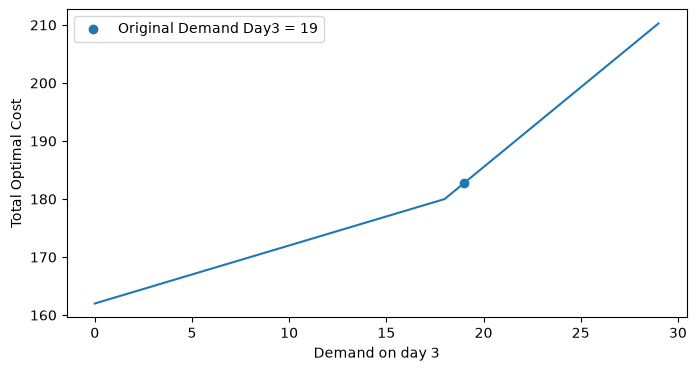

In [11]:
demands = [napkins_demanded['day3']+ epsilon for epsilon in range(-19,11)]
fig, ax =plt.subplots(figsize=(8,4))
ax.plot(demands,total_costs)
ax.scatter(19,total_costs[demands.index(19)], label='Original Demand Day3 = 19')
plt.legend()
ax.set_ylabel('Total Optimal Cost')
ax.set_xlabel('Demand on day 3')
# ax.vlines(19, 160, 170)

### Changing the inventory of the napkin supplier

In [12]:
%%time
total_costs = []
napkins_supplier = [] 

for new_inventory in range(125,37,-1):
    New_Network = Catering_Network.copy()

    New_Network.nodes['P_0'] = Node('P_0',balance=new_inventory)
    New_Network.nodes['Q_0'] = Node('Q_0',balance=-new_inventory)

    try:
        Results = NetworkSimplex(New_Network).solve()
        total_costs.append(Results.objective_value)
        napkins_supplier.append(new_inventory)
    except Exception as e:
        print(f'Napkins {new_inventory} - Infactible Error: {e}')

Napkins 39 - Infactible Error: No feasible flow satisfies the node balances.
Napkins 38 - Infactible Error: No feasible flow satisfies the node balances.
CPU times: total: 188 ms
Wall time: 184 ms


The problem is not feasible when the supplier offers less than 40 napkins

### Changing the pricec of Napkins and the laundering costs

In [13]:
Baseline_ARCS = []
# Arcs with respect to Q_0 (auxiliary node)
Baseline_ARCS.append(
        Arc(id=f'P_0 -> Q_0',
            tail='P_0', 
            head='Q_0',
            cost=0)
    )
Baseline_ARCS.append(
        Arc(id=f'P_7 -> Q_0',
            tail='P_7', 
            head='Q_0',
            cost=0)
    )
# Arcs from P_0 to all Q_i (buying napkins from the supplier)
for i in Q_nodes_names[1:]:
    Baseline_ARCS.append(
        Arc(id=f'P_0 -> {i}',
            tail=P_nodes_names[0], 
            head=i,
            cost=3)
    )

# Carrying napkins from day i to day i+1 (cost=0)
for i in range(1,7):
    Baseline_ARCS.append(
        Arc(id=f'{P_nodes_names[i]} -> {P_nodes_names[i+1]}',
            tail=P_nodes_names[i], 
            head=P_nodes_names[i+1],
            cost=0)
    )
def create_network_with_costs(fast_cost, slow_cost):
    """Crea una red con costos de lavado específicos."""
    N_Arcs = Baseline_ARCS.copy()
    # Arcs from P_i to Q_j (delivery of napkins) 
    for i,Pnode in enumerate(P_nodes_names[1:]):
        i+=1 # to correct zero indexing
        if i+4 <=7: 
            # SLOW DELIVERY (4 days)
            N_Arcs.append(
                Arc(id=f'{Pnode} -> {Q_nodes_names[i+4]}',
                    tail=Pnode, 
                    head=Q_nodes_names[i+4],
                    cost=slow_cost)
            )
            # FAST DELIVERY (2 days)
            N_Arcs.append(
                        Arc(id=f'{Pnode} -> {Q_nodes_names[i+2]}',
                            tail=Pnode, 
                            head=Q_nodes_names[i+2],
                            cost=fast_cost)
                    )

        elif i+2 <=7:
            # Only FAST DELIVERY available (2 days)
            N_Arcs.append(
                        Arc(id=f'{Pnode} -> {Q_nodes_names[i+2]}',
                            tail=Pnode, 
                            head=Q_nodes_names[i+2],
                            cost=fast_cost)
                    )
    Catering_Network = Network(Data_NODES, N_Arcs)
    return Catering_Network



In [14]:
import numpy as np
fast_costs = np.linspace(0, 3, 50)  # 20 points
slow_costs = np.linspace(0, 3, 50)  # 20 points
F, S = np.meshgrid(fast_costs, slow_costs, indexing='ij')
# Matrix for results 
cost_matrix = np.zeros_like(F, dtype=float)
iteration_matrix = np.zeros_like(F, dtype=float)
base_matrix = np.empty_like(F, dtype=object)  

In [15]:
import time
start_time = time.time()
for i in range(F.shape[0]):      # fast_costs
    for j in range(F.shape[1]):  # slow_costs
        fast_cost = F[i, j]
        slow_cost = S[i, j]
        
        try:
            # Build the new network
            network = create_network_with_costs(fast_cost, slow_cost)
            
            # Resolver
            problem = NetworkSimplex(network)
            result = problem.solve()
            
            # Guardar resultados
            cost_matrix[i, j] = result.objective_value
            iteration_matrix[i, j] = result.iterations
            base_matrix[i, j] = result.basic_arc_ids
            
        except Exception as e:
            cost_matrix[i, j] = np.nan
            iteration_matrix[i, j] = np.nan
            base_matrix[i, j] = None
            print(f" Fast={fast_cost:.2f}, Slow={slow_cost:.2f}: {e}")

end_time = time.time()
print(f"Completed in {end_time - start_time:.2f} seconds. Solved {F.shape[0]*S.shape[1]} problems")


Completed in 3.52 seconds. Solved 2500 problems


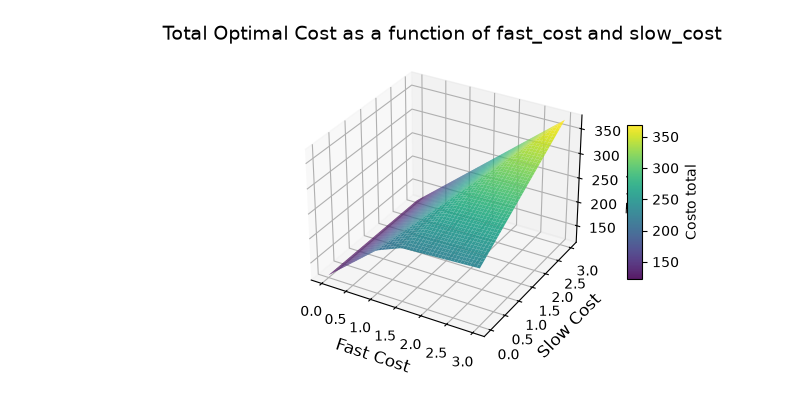

In [16]:
# from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%matplotlib widget
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(F, S, cost_matrix, cmap=cm.viridis, 
                       alpha=0.9, linewidth=0, antialiased=True)

ax.set_xlabel('Fast Cost', fontsize=12)
ax.set_ylabel('Slow Cost', fontsize=12)
ax.set_zlabel('Total Cost', fontsize=12)
ax.set_title('Total Optimal Cost as a function of fast_cost and slow_cost', fontsize=14)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Costo total')

plt.show()

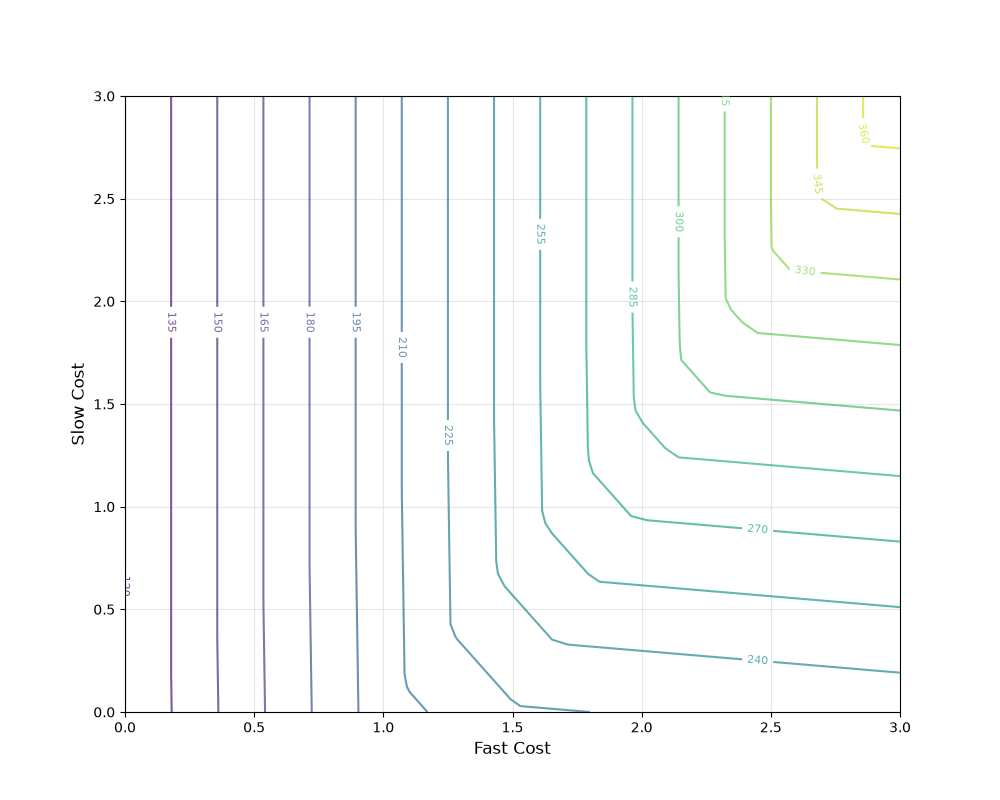

In [17]:
fig, ax = plt.subplots(figsize=(10,8 ))

#Contornos de costo
contour = ax.contour(F, S, cost_matrix, levels=20, cmap='viridis', alpha=0.7)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_xlabel('Fast Cost', fontsize=12)
ax.set_ylabel('Slow Cost', fontsize=12)
# ax.set_title('Contour Plot', fontsize=14)
ax.grid(True, alpha=0.3)

plt.show()

### Region of stability in the schedule

In [18]:
def flows_are_equal(flow1, flow2, tolerance=1e-9):
    """Compara dos diccionarios de flujos con tolerancia."""
    if set(flow1.keys()) != set(flow2.keys()):
        return False
    for key in flow1:
        if abs(flow1[key] - flow2[key]) > tolerance:
            return False
    return True

def get_flow_signature(flows, tolerance=1e-9):
    return tuple(round(flow, 2) for flow in flows.values())

In [19]:
catering_simplex_problem = NetworkSimplex(Catering_Network)
catering_solution = catering_simplex_problem.solve()
original_shedule = catering_solution.flows

stable_region = np.zeros_like(F, dtype=bool)

start_time = time.time()

for i in range(F.shape[0]):      # fast_costs
    for j in range(F.shape[1]):  # slow_costs
        fast_cost = F[i, j]
        slow_cost = S[i, j]
        
        try:
            # Build the new network
            network = create_network_with_costs(fast_cost, slow_cost)
            
            # Solve
            problem = NetworkSimplex(network)
            result = problem.solve()

            result.flows
            is_equal = flows_are_equal(original_shedule,result.flows)
            stable_region[i, j] = is_equal
            # Save

                
            
        except Exception as e:
            stable_region[i, j] = False
            print(f" Fast={fast_cost:.2f}, Slow={slow_cost:.2f}: {e}")

end_time = time.time()

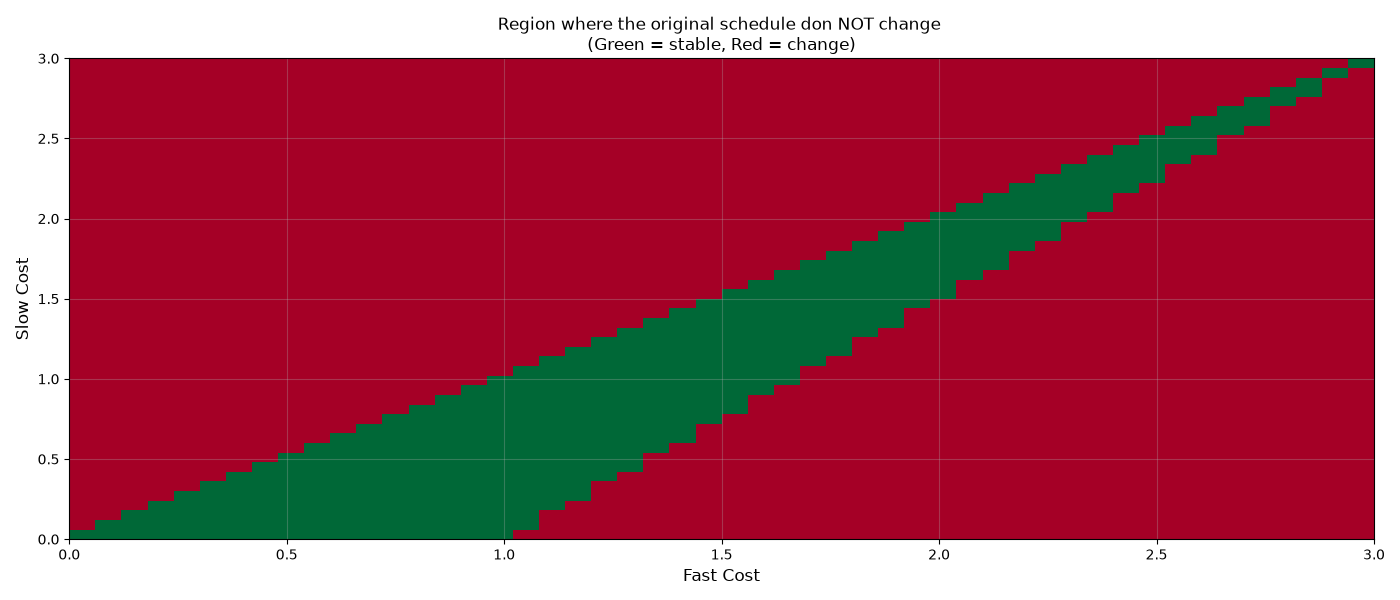

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

im1 = ax.imshow(stable_region.T, origin='lower',
                 extent=[fast_costs[0], fast_costs[-1], slow_costs[0], slow_costs[-1]],
                 aspect='auto', cmap='RdYlGn')
ax.set_xlabel('Fast Cost', fontsize=12)
ax.set_ylabel('Slow Cost', fontsize=12)
ax.set_title('Region where the original schedule don NOT change \n(Green = stable, Red = change)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [21]:
%%time
total_costs = []

for epsilon in range(-19,11):
    new_demand = napkins_demanded['day3'] +epsilon
    New_Network = Catering_Network.copy()

    # Change in demands
    New_Network.nodes['P_0'] = Node('P_0', balance=enough_napkins+epsilon)
    New_Network.nodes['Q_0'] = Node('Q_0', balance=-enough_napkins-epsilon)
    New_Network.nodes['P_3'] = Node('P_3', balance=new_demand)
    New_Network.nodes['Q_3'] = Node('Q_3', balance=-new_demand)

    #warm_start with the basis provided before
    warm = WarmStart(
        root=warm_start.root,
        basic_arc_ids=warm_start.basic_arc_ids,
        flows=dict(warm_start.flows)  # Nuevo diccionario
        )
    # change in flows
    warm.flows['P_0 -> Q_3'] = new_demand
    warm.flows['P_7 -> Q_0'] += epsilon
    for i in range(3,7):
        warm.flows[f'P_{i} -> P_{i+1}'] += epsilon
    
    # Solving
    Results = NetworkSimplex(New_Network).solve(warm_start=warm)
    total_costs.append(Results.objective_value)

    

CPU times: total: 46.9 ms
Wall time: 38.1 ms
